In [16]:
import xarray as xr
import numpy as np

In [2]:
from xmitgcm.llcreader import faces_dataset_to_latlon

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import cartopy
import cartopy.feature as cf

from cartopy import crs as ccrs

In [4]:
def open_llc4320_velocity_data(chunks='auto'):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
        
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
    return ds, ds_grid

In [5]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [6]:
latlon_grid = faces_dataset_to_latlon(ds_grid).set_coords(['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG'])

/srv/conda/envs/notebook/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:322: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(ifac * coords.dims[vname])
/srv/conda/envs/notebook/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:324: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(jfac * coords.dims[vname])


In [7]:
depth = latlon_grid['Depth']
depth.name = None  # needed to avoid confusing hvplot when it calls .to_dataset()
depth

<xarray.DataArray (j: 12960, i: 17280)> Size: 896MB
dask.array<concatenate, shape=(12960, 17280), dtype=float32, chunksize=(4320, 4320), chunktype=numpy.ndarray>
Coordinates:
  * i        (i) int64 138kB 0 1 2 3 4 5 ... 17274 17275 17276 17277 17278 17279
  * j        (j) int64 104kB 0 1 2 3 4 5 ... 12954 12955 12956 12957 12958 12959
    XC       (j, i) float32 896MB dask.array<chunksize=(4320, 4320), meta=np.ndarray>
    YC       (j, i) float32 896MB dask.array<chunksize=(4320, 4320), meta=np.ndarray>
Attributes:
    coordinate:     XC YC
    long_name:      ocean depth
    standard_name:  ocean_depth
    units:          m

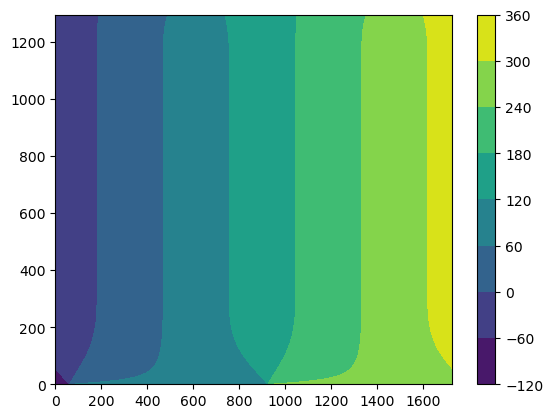

In [8]:
XC1 = depth.XC
XC2 = XC1.copy()
XC2[:,2000:] = XC1[:,2000:].where(XC1[:,2000:]>0,XC1[:,2000:]+360)
cs = plt.contourf(XC2.coarsen(i=10,j=10).mean())
plt.colorbar(cs)

NameError: name 'vertices' is not defined

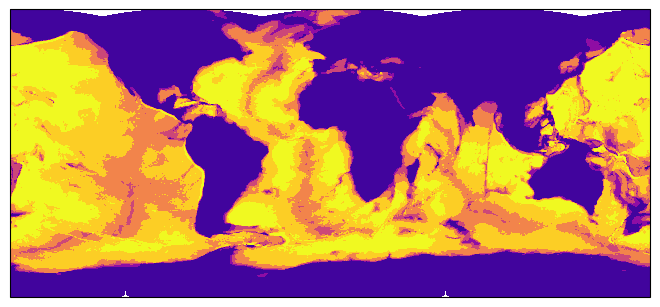

In [11]:
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.PlateCarree())
ax.contourf(XC2.coarsen(i=10,j=10).mean().values, depth.coarsen(i=10,j=10).mean().YC.values, depth.coarsen(i=10,j=10).mean().values,
                transform=ccrs.PlateCarree(),vmax=5000,cmap='plasma')


ax.add_geometries([vertices.isel(region=1)], ccrs.PlateCarree(),
                          facecolor='m', edgecolor='k')

In [12]:
target_url ='gs://leap-persistent/cspencerjones/hero-calc/masked_hist_renorm_3hr.zarr'
hist_ds = xr.open_dataset(target_url, engine="zarr", chunks={})

In [13]:
from xarray.indexes import PandasIndex

# have to add the index ourselves manually for some reason
hist_ds = hist_ds.set_xindex('region_num', PandasIndex)

In [14]:
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (region: 437, vertices: 4, div_bin: 99,
                                time: 37, vort_bin: 99, strain_bin: 49)
Coordinates:
    j_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
  * region_num                 (region) int64 3kB 4 5 6 7 13 ... 792 793 798 799
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    i_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
    face                       (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

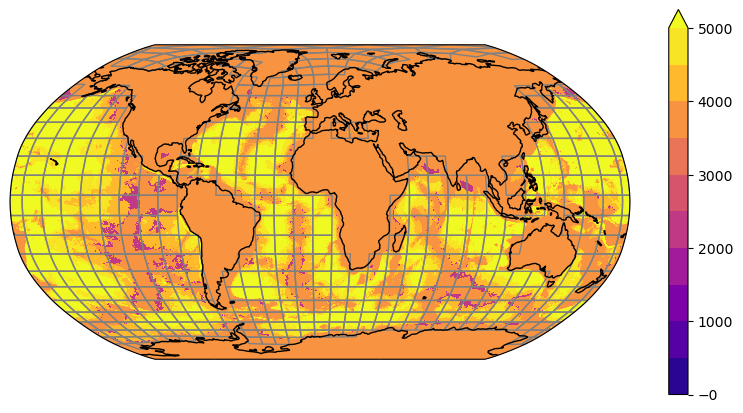

In [49]:
fig = plt.figure(figsize=(10, 5))
plt.clf()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
cs = ax.contourf(XC2.coarsen(i=10,j=10).mean().values, depth.coarsen(i=10,j=10).mean().YC.values, depth.coarsen(i=10,j=10).mean().values,
                transform=ccrs.PlateCarree(),levels=np.arange(-0.5,5000,500),vmax=5000,cmap='plasma',extend='max')#,levels=np.arange(0,5000,100)
plt.colorbar(cs,extend='max')

# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hist_ds.j_region_coarse, edgecolors='grey',facecolors='None', transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view
#ax.gridlines(draw_labels=["left", "right"])
fig.savefig('depth_grid.png')

In [43]:
np.arange(-0.5,5000,250)

array([-5.0000e-01,  2.4950e+02,  4.9950e+02,  7.4950e+02,  9.9950e+02,
        1.2495e+03,  1.4995e+03,  1.7495e+03,  1.9995e+03,  2.2495e+03,
        2.4995e+03,  2.7495e+03,  2.9995e+03,  3.2495e+03,  3.4995e+03,
        3.7495e+03,  3.9995e+03,  4.2495e+03,  4.4995e+03,  4.7495e+03,
        4.9995e+03])

In [48]:
540/9

60.0